In [1]:
import sys
sys.path.append('/SAN/colcc/Hormad1/projects/MINOTAUR')
sys.path.append('/SAN/colcc/Hormad1/projects/MINOTAUR/tiler')

import torch
import pandas as pd
import numpy as np
import pytorch_lightning as pl
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from typing import Optional, Dict, Any, Tuple
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

from arg_def import Args
import cem_mil.train.utils as utils
from cem_mil.models.cem_mil import ConceptEmbeddingModel
from loader.tile_loader import TileDataset, MultinominalSampler

/opt/conda/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


['/opt/conda/lib/python310.zip', '/opt/conda/lib/python3.10', '/opt/conda/lib/python3.10/lib-dynload', '', '/home/verghese/.local/lib/python3.10/site-packages', '/opt/conda/lib/python3.10/site-packages', '/SAN/colcc/Hormad1/projects/MINOTAUR', '/SAN/colcc/Hormad1/projects/MINOTAUR/tiler', '/opt/conda/lib/python3.10/site-packages/setuptools/_vendor', '/tmp/5576313.1.gpu.q/tmpo1n709e5']


In [2]:
from scipy.special import softmax

In [3]:
DB_PATH = '/SAN/colcc/Hormad1/data/embeddings/uni/224-20x-0.2'
#db_path = '/Users/k2030634/PhD/Isambard/data/features'

In [4]:
#CONCEPTS = ['Stage', 'Age', 'Cancer'] 
#bin_pcanc_train_cohort = pd.read_csv('/SAN/colcc/Hormad1/data/datasets/cat_stcanage_60surv_train_cohort.csv')
bin_pcanc_train_cohort = pd.read_csv('/SAN/colcc/Hormad1/data/datasets/bin_stcanage_60surv_train_v2.csv')

In [5]:
x = pd.read_csv('/SAN/colcc/Hormad1/data/datasets/cat_val_ids.csv')
val_ids = list(x['0'])

In [6]:
import os
import pandas as pd

test = pd.read_csv('/home/verghese/val_check_ids.csv')
test = list(test['ids'])
test = [os.path.basename(t)[:-4] for t in test]

set(test)- set(val_ids)

set()

In [7]:
#pcanc_train_cohort['stratify_col'] = pcanc_train_cohort[CONCEPTS[:2]].astype(str).agg('-'.join, axis=1)

#train_df, val_df = train_test_split(
#    pcanc_train_cohort, 
#    test_size=0.2, 
#    stratify=pcanc_train_cohort['stratify_col'], 
#    random_state=42
#)

#train, val = list(train_df['ID']), list(val_df['ID'])
#pcanc_train_cohort['test'] = pcanc_train_cohort['ID'].apply(lambda x: 1 if x in train else 0)

bin_pcanc_train_cohort['test'] = bin_pcanc_train_cohort['ID'].apply(lambda x: 0 if x in val_ids else 1)

In [8]:
#df = pd.DataFrame(val)
#df.to_csv('cat_val_ids.csv')

In [9]:
def get_val_dloader(
        val_data,
        args: Any,
        ) -> Tuple[Optional[DataLoader], Optional[DataLoader]]:
        """
        Sets up the data loaders for training and validation.

        Args:
            args: Namespace, model arguments.
            with_data: Boolean, if True loads data.

        Returns:
            Tuple[DataLoader, DataLoader]: Train and validation data loaders.
        """
        print(args.bag_n)
        val_dataset = TileDataset(val_data, args.db_path, args.target, args.cpt_ids, args.bag_n)
        val_dloader = DataLoader(
            val_dataset, 
            batch_size=4, 
            num_workers = 8)

        return val_dloader

In [10]:
args = Args(DB_PATH)
train_data = bin_pcanc_train_cohort[bin_pcanc_train_cohort['test']==1]
val_data = bin_pcanc_train_cohort[bin_pcanc_train_cohort['test']==0]
val_dloader = get_val_dloader(val_data=val_data,args=args)

3000
db_path /SAN/colcc/Hormad1/data/embeddings/uni/224-20x-0.2
greg 330
Loading 329%num bags 330


In [11]:
N_CONCEPTS = 17
#CONCEPT_STATES = [4, 3, 10]
CONCEPT_STATES = None
N_TASKS = 1
H_DIM = 1024
EMB_SIZE = 8
PRE_BN_ML = True
ACT = "LeakyReLU"

In [12]:
#attention callback to log attention
attention_hook = utils.AttentionHook()
atten_callback = utils.SaveAttentionCallback(
    attention_hook=attention_hook
)

In [13]:
PRE_BN_ML

True

In [26]:
cem_model = ConceptEmbeddingModel.load_from_checkpoint(
    #"/SAN/colcc/Hormad1/projects/MINOTAUR/workbooks/binvsrest_10_cca_noweights_model_check.ckpt",
    "/SAN/colcc/Hormad1/analysis/minotaur/bin_model_exv10/3000_True_8_10_0.3_attention_exp0_noweights_checkmodel.ckpt",
    n_concepts=N_CONCEPTS, 
    concept_states=CONCEPT_STATES,
    n_tasks=N_TASKS, 
    h_dim=H_DIM,
    pre_bn_mlp=PRE_BN_ML,
    emb_size=EMB_SIZE,
    embedding_activation=ACT,
    concept_loss_weight=10,
    concept_class_weights=torch.tensor([1]*17),
    learning_rate=1e-3,  
    dropout=0.3,
    optimizer="adam",  
    attention_hook=attention_hook)

prmsssss
17
1
1024
8
None
LeakyReLU
False
10
1
None
tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])
1
256
0.4
0.3
True
None
None
adam
0.9
0.001
4e-05
1
None
weights tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])
c2y model Sequential(
  (0): Linear(in_features=136, out_features=1, bias=True)
)
concept weights 17


In [27]:
from sklearn.metrics import accuracy_score, auc, f1_score

In [28]:
x_test, y_test, c_test = [], [], []
for (x, y, c) in val_dloader:
    x_test.append(x)
    y_test.append(y)
    c_test.append(c)
x_test = np.concatenate(x_test, axis=0)
y_test = np.concatenate(y_test, axis=0)
c_test = np.concatenate(c_test, axis=0)


trainer_pred = pl.Trainer(
    accelerator="cpu",
    devices="auto",
    logger=False,
)

batch_results = trainer_pred.predict(cem_model, val_dloader)

Dataset length: 330


GPU available: True (cuda), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Dataset length: 330
Dataset length: 330


/opt/conda/lib/python3.10/site-packages/pytorch_lightning/trainer/setup.py:177: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.


Dataset length: 330
Dataset length: 330
Predicting DataLoader 0:   0%|          | 0/83 [00:00<?, ?it/s]

/opt/conda/lib/python3.10/site-packages/torch/nn/modules/module.py:1736: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)


Predicting DataLoader 0: 100%|██████████| 83/83 [00:51<00:00,  1.60it/s]
Dataset length: 330


In [29]:
#np.load('/home/verghese/x_test.npy')

In [30]:
#np.save('/SAN/colcc/Hormad1/c_test.npy',c_test)

In [31]:
def get_cptprobs2(results):
    c_probs = np.concatenate(
        list(map(lambda x: x[0].detach().cpu().numpy(), results)),
        axis=0,
    )
    return c_probs

In [32]:
def get_yprobs(results):
    y_probs = np.concatenate(
        list(map(lambda x: torch.nn.Sigmoid()(x[2]).detach().cpu().numpy(), results)),
        axis=0,
    )
    return y_probs

In [33]:
def get_cembs(results):
    c_embs = np.concatenate(
        list(map(lambda x: x[1].detach().cpu().numpy(), batch_results)),
        axis=0,
    )
    # Reshape (batch_size, k, emb_size)
    c_embs = np.reshape(c_embs, (c_test.shape[0], c_test.shape[1], -1))
    return c_embs

In [34]:
def get_contexts(results):
    contexts = np.concatenate(
        list(map(lambda x: x[5].detach().cpu().numpy(), batch_results)),
        axis=0,
    )
    
    #contexts = np.reshape(c_embs, (c_test.shape[0], c_test.shape[1], -1))
    return contexts

In [35]:
y_probs = get_yprobs(batch_results)

In [36]:
#concept_states = [4, 3, 10] 
c_probs = get_cptprobs2(batch_results)
c_embs = get_cembs(batch_results)
ctxts = get_contexts(batch_results)

In [37]:
c_probs

array([[-2.1617362 ,  0.51021737, -0.34853113, ..., -4.6472545 ,
        -4.656379  , -2.6960614 ],
       [-2.0182738 ,  0.46975702, -0.23820512, ..., -3.9763079 ,
        -4.540215  , -2.755984  ],
       [-3.0478346 ,  0.5756022 , -1.899055  , ..., -3.6592526 ,
        -2.5650227 , -2.8410122 ],
       ...,
       [-4.128514  ,  0.57169545, -2.723349  , ..., -2.907043  ,
         1.2372625 , -2.728834  ],
       [-3.2765484 ,  0.75469613, -1.8518264 , ..., -3.2418795 ,
         0.91870344, -3.1556523 ],
       [-1.4067807 ,  0.1066445 , -1.4057667 , ...,  1.1583313 ,
        -2.4536612 , -2.5382493 ]], dtype=float32)

In [38]:
test = np.load('/SAN/colcc/Hormad1/analysis/minotaur/bin_model_exv10/10_cprobs_check.npy')

In [39]:
test

array([[-2.158623  ,  0.5095004 , -0.35281384, ..., -4.6823177 ,
        -4.709732  , -2.6927783 ],
       [-2.004635  ,  0.45543095, -0.22492667, ..., -3.9383655 ,
        -4.567532  , -2.7481444 ],
       [-3.0706992 ,  0.6238835 , -1.9133606 , ..., -3.6508706 ,
        -2.5464585 , -2.8501234 ],
       ...,
       [-4.1416926 ,  0.5701016 , -2.723202  , ..., -2.9122498 ,
         1.2444862 , -2.7342014 ],
       [-3.2532148 ,  0.7606581 , -1.8730493 , ..., -3.2337208 ,
         0.97273886, -3.1540887 ],
       [-1.4436841 ,  0.10669178, -1.3860464 , ...,  1.0220014 ,
        -2.4246821 , -2.5421712 ]], dtype=float32)

In [40]:
def get_bin_concept_metrics(c_probs, c_test):
    c_f1s, c_accuracies, idx = [], [], 0
    for i, n in enumerate(range(c_probs.shape[-1])):
        cpt_probs = c_probs[:,i]
        cpt_probs = torch.tensor(cpt_probs)
        cpt_probs = torch.nn.Sigmoid()(cpt_probs).cpu().numpy()
        c = c_test[:, i]
        c_accuracies.append(accuracy_score(cpt_probs>=0.5, c))
        c_f1s.append(f1_score(c,cpt_probs>0.5))

    return c_accuracies, c_f1s 

In [41]:
c_test

array([[0., 0., 1., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 1., 0., ..., 0., 1., 0.],
       [0., 1., 0., ..., 0., 1., 0.],
       [0., 0., 1., ..., 1., 0., 0.]], dtype=float32)

In [44]:
c_test_2 = np.load('/home/verghese/c_test.npy')

In [46]:
np.unique(c_test_2==c_test)

array([ True])

In [47]:
c_accuracies, c_f1s = get_bin_concept_metrics(test, c_test)

In [48]:
c_f1s

[0.34710743801652894,
 0.5432098765432098,
 0.0547945205479452,
 0.4175824175824176,
 0.017699115044247787,
 0.049586776859504134,
 0.2953020134228188,
 0.6492146596858639,
 0.7796610169491526,
 0.7478260869565218,
 0.42857142857142855,
 0.9090909090909091,
 0.2222222222222222,
 0.6190476190476191,
 0.7578947368421053,
 0.9142857142857143,
 0.0]

In [ ]:
avg_f1 = np.mean(c_f1s)
avg_accs = np.mean(c_accuracies)

In [ ]:
task_accuracy = accuracy_score(y_test, y_probs >=0.5)
print(f"Our CEM's test task accuracy is {task_accuracy*100:.2f}%")

f1 = f1_score(y_test, y_probs >=0.5)
print(f"Our CEM's test task f1 is {f1*100:.2f}%")

roc = roc_auc_score(y_test, y_probs)
roc

In [86]:
df = pd.DataFrame({
    'names':['10'], 
    'task_f1s':[f1], 
    'task_accs': [task_accuracy], 
    'task_rocs': [roc],
    'concepts_avg_accs': [avg_accs], 
    'concepts_avg_f1s': [avg_f1],
    'c_f1s': [c_f1s]
})

print(df)

  names  task_f1s  task_accs  task_rocs  concepts_avg_accs  concepts_avg_f1s  \
0    10  0.701235   0.633333   0.663588           0.849733          0.593931   

                                               c_f1s  
0  [0.5172413793103449, 0.21374045801526717, 0.09...  


In [87]:
df.to_csv('10.csv')

In [ ]:
test = np.load('/SAN/colcc/Hormad1/mc_y_probs.npy')

In [78]:
np.save('/SAN/colcc/Hormad1/bin_y_probs.npy', y_probs)

### Multiclass

In [75]:
c_f1s

[0.06315789473684211,
 0.525679758308157,
 0.0,
 0.0,
 0.3681592039800995,
 0.049586776859504134,
 0.3424657534246575,
 0.9256198347107438,
 0.7058823529411765,
 0.7792207792207793,
 0.8695652173913043,
 0.8435374149659864,
 0.6923076923076923,
 0.34285714285714286,
 0.8333333333333334,
 0.9714285714285714,
 0.0]

In [23]:
#np.save('/SAN/colcc/Hormad1/mc_y_probs.npy', y_probs)

In [35]:
task_accuracy = accuracy_score(y_test, y_probs >=0.5)
print(f"Our CEM's test task accuracy is {task_accuracy*100:.2f}%")

f1 = f1_score(y_test, y_probs >=0.5)
print(f"Our CEM's test task f1 is {f1*100:.2f}%")

roc = roc_auc_score(y_test, y_probs)

Our CEM's test task accuracy is 66.67%
Our CEM's test task f1 is 70.74%


NameError: name 'roc_auc_score' is not defined

In [37]:
def get_concept_metrics(c_probs):
    c_f1s, c_accs, idx = [], [], 0
    c_pred_lst = []
    probs_lst = []
    for i, n in enumerate(concept_states):
        n_idx = idx+n
        c_probs_states = c_probs[:,idx:n_idx]
        c_probs_states = softmax(c_probs_states,axis=-1)
        print('print',np.sum(c_probs_states[0]),c_probs_states.shape)
        probs_lst.append(c_probs_states)
        c_pred = np.argmax(c_probs_states, axis=-1)
        c_pred_lst.append(c_pred)
        c = c_test[:, i]
        
        c_accs.append(accuracy_score(c_pred, c))
        c_f1s.append(f1_score(
            c,
            c_pred,
            average='macro',
        ))

        idx = n_idx

    return c_f1s, c_accs, c_f1s, c_pred_lst, probs_lst

In [38]:
concept_states = [4, 3, 10] 
c_probs = get_cptprobs2(batch_results)
c_embs = get_cembs(batch_results)
ctxts = get_contexts(batch_results)
c_avg_f1, c_avg_accuracy, c_avg_roc_auc, c_pred_lst, probs = get_concept_metrics(c_probs)
#c_avg_f1

print 1.0 (330, 4)
print 1.0 (330, 3)
print 1.0 (330, 10)


In [39]:
c_avg_f1

[0.493903364169728, 0.41950727082165146, 0.8572108473295966]

In [52]:
np.unique(c_test[:,0])

array([0., 1., 2., 3.], dtype=float32)

In [59]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import precision_recall_curve, average_precision_score

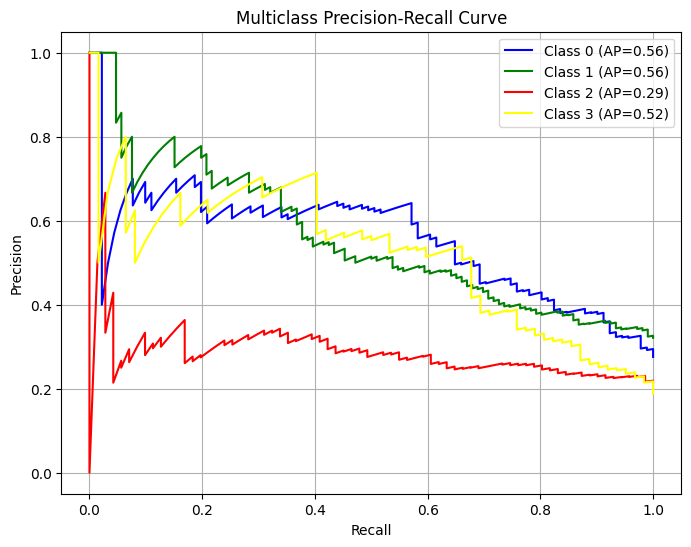

In [57]:
y_test_bin = label_binarize(c_test[:,0], classes=np.unique(c_test[:,0]))
n_classes = y_test_bin.shape[1]

# Step 6: Compute precision-recall curve and average precision for each class
precision = dict()
recall = dict()
average_precision = dict()

for i in range(n_classes):
    precision[i], recall[i], _ = precision_recall_curve(y_test_bin[:, i], probs[0][:, i])
    average_precision[i] = average_precision_score(y_test_bin[:, i], probs[0][:, i])

# Step 7: Plot precision-recall curves for each class
plt.figure(figsize=(8, 6))

colors = ['blue', 'green', 'red', 'yellow']  # Colors for each class curve

for i in range(n_classes):
    plt.plot(recall[i], precision[i],
             label=f'Class {i} (AP={average_precision[i]:0.2f})',
             color=colors[i])

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Multiclass Precision-Recall Curve')
plt.legend(loc='best')
plt.grid(True)
plt.show()

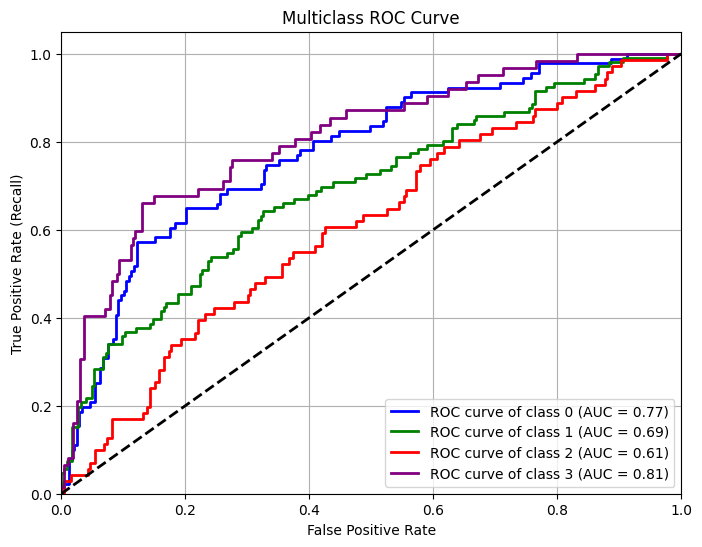

In [60]:
y_test_bin = label_binarize(c_test[:,0], classes=np.unique(c_test[:,0]))
n_classes = y_test_bin.shape[1]

# Step 6: Compute ROC curve and AUC for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], probs[0][:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Step 7: Plot ROC curves
plt.figure(figsize=(8, 6))

colors = ['blue', 'green', 'red', 'purple']  # Customize colors as needed

for i in range(n_classes):
    plt.plot(fpr[i], tpr[i],
             color=colors[i],
             lw=2,
             label=f'ROC curve of class {i} (AUC = {roc_auc[i]:0.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)  # Diagonal dashed line (random guessing)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('Multiclass ROC Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

In [147]:
sns.kdeplot(probs[3], fill=True)
plt.title("Age predicted binary probabilities")
plt.show()

IndexError: list index out of range

In [66]:
np.set_printoptions(suppress=True)
c_probs[0]

array([0.00000102, 0.00031308, 0.00000989, 0.00000002, 0.00007116,
       0.00000121, 0.00000064, 0.99958223, 0.00000097, 0.00001505,
       0.00000013, 0.00000026, 0.00000005, 0.0000001 , 0.0000037 ,
       0.00000047, 0.00000002], dtype=float32)

In [120]:
np.save('/SAN/colcc/Hormad1/y_labels.npy', y_test)

In [136]:
np.save('/SAN/colcc/Hormad1/mc_stage_c_probs.npy', probs[0])
np.save('/SAN/colcc/Hormad1/mc_age_c_probs.npy', probs[1])
np.save('/SAN/colcc/Hormad1/mc_cancer_c_probs.npy', probs[2])

In [139]:
np.save('/SAN/colcc/Hormad1/mc_c_test.npy', c_test)

In [137]:
np.save('/SAN/colcc/Hormad1/mc_cpt_state_embedds.npy', ctxts)

In [146]:
y_test.shape, c_test.shape, probs[2].shape, ctxts.shape

((330,), (330, 3), (330, 10), (330, 17, 8))

In [ ]:
#np.save('/SAN/colcc/Hormad1/ctxts.npy',ctxts)
#pd.DataFrame(y_test).to_csv('/SAN/colcc/Hormad1/y_labels.csv')
#pd.DataFrame(c_probs).to_csv('/SAN/colcc/Hormad1/concept_state_probs.csv')

In [50]:
#c_embs.shape
#num_parts
#reshaped_tensor.shape
#reshaped_tensor.shape[0]/c_embs.shape[1]

reshaped_tensor = c_embs.reshape(-1, 16)
#num_parts = int(reshaped_tensor.shape[0]/c_embs.shape[1])
#num_concepts = 17

In [51]:
reshaped_tensor.shape

(495, 16)

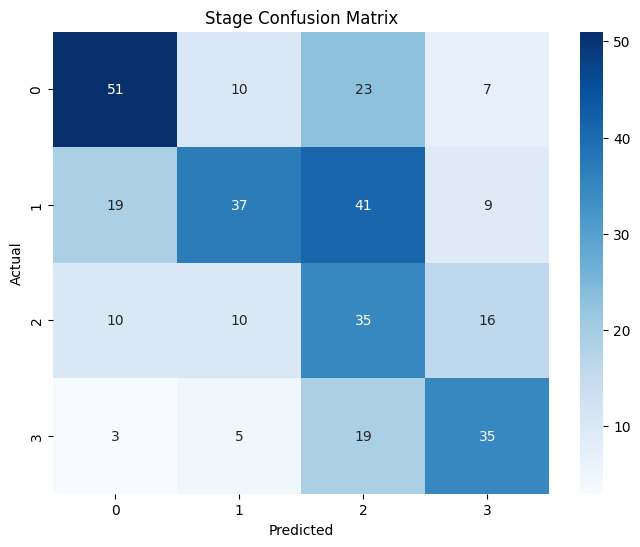

In [48]:
c_pred_lst[0]
c_true = c_test[:,0]
cm = confusion_matrix(c_true, c_pred_lst[0])
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Stage Confusion Matrix")
plt.show()

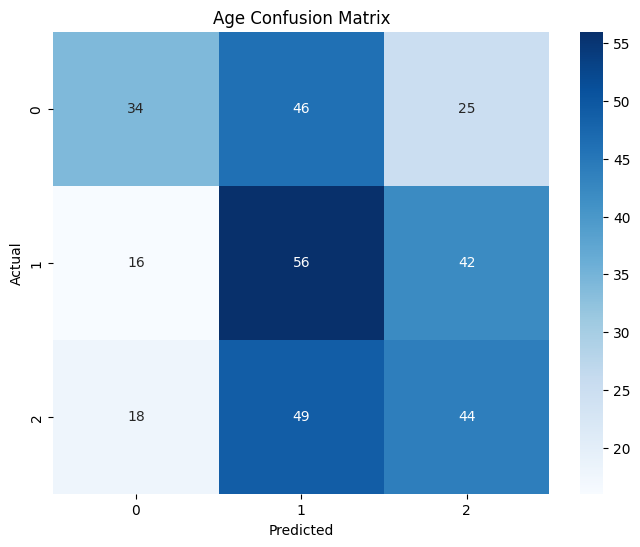

In [51]:
c_true = c_test[:,1]
cm = confusion_matrix(c_true, c_pred_lst[1])
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Age Confusion Matrix")
plt.show()

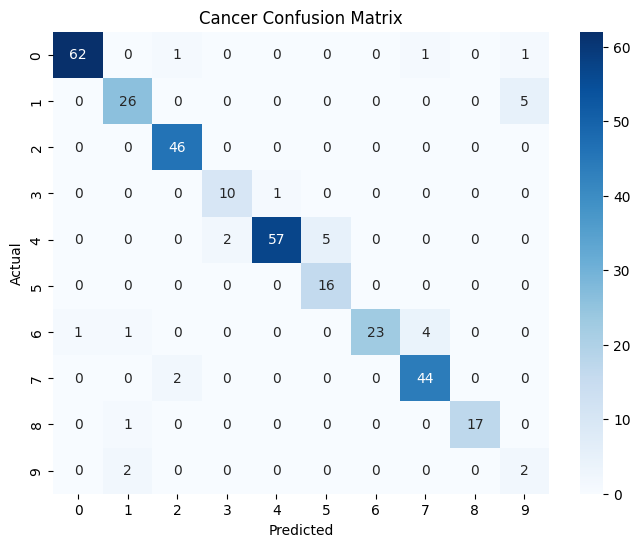

In [53]:
c_true = c_test[:,2]
cm = confusion_matrix(c_true, c_pred_lst[2])
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Cancer Confusion Matrix")
plt.show()

In [ ]:
age_pred = c_pred_lst[1]
y_true = c_test[:,1]

acceptable = {
    1: {2},
    2: {1, 3},
    3: {2}
}

# Adjust predictions to reflect acceptable misclassifications
y_pred_adj = age_pred.copy()
for i, (yt, yp) in enumerate(zip(y_true, age_pred)):
    if yt != yp and yp in acceptable.get(yt, set()):
        y_pred_adj[i] = yt  # treat as correct by converting to the true label

# Calculate standard macro F1 score on adjusted predictions
effective_f1 = f1_score(y_true, y_pred_adj, average='macro')

print("Effective F1 score (with tolerances):", effective_f1)